In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
BASE_PATH = "../data/raw"

train = pd.read_csv(f"{BASE_PATH}/train.csv")
stores = pd.read_csv(f"{BASE_PATH}/stores.csv")
oil = pd.read_csv(f"{BASE_PATH}/oil.csv")
holidays = pd.read_csv(f"{BASE_PATH}/holidays_events.csv")

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [8]:
sales = train.groupby("date")["sales"].sum()
sales.index = pd.to_datetime(sales.index)

sales.head()

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
Name: sales, dtype: float64

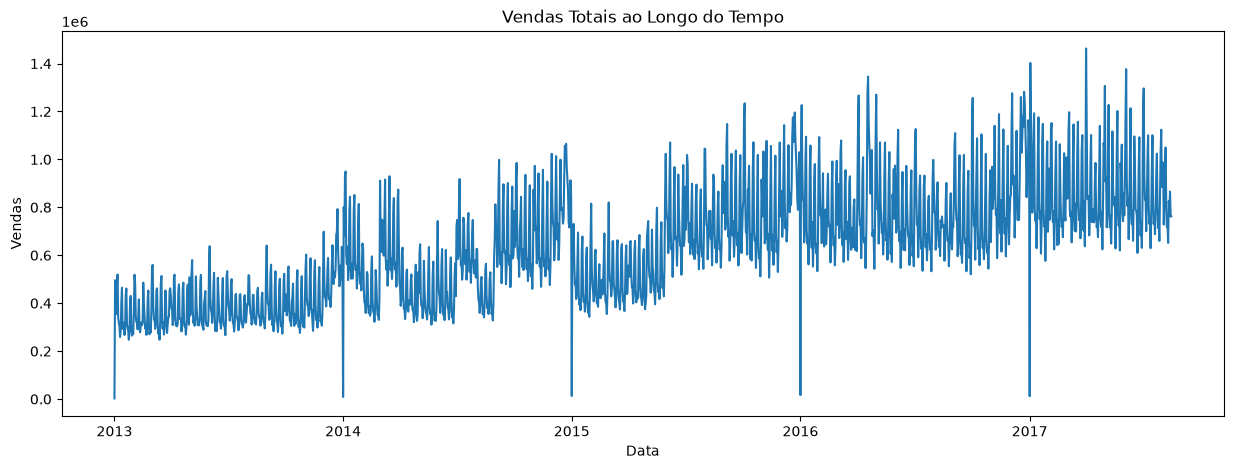

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(sales)
plt.title("Vendas Totais ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()

In [10]:
sales.isnull().sum()

np.int64(0)

In [11]:
sales.index.min(), sales.index.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [12]:
sales.index.to_series().diff().value_counts().head()

date
1 days    1679
2 days       4
Name: count, dtype: int64

In [15]:
sales = sales.ffill()

In [16]:
sales.isnull().sum()

np.int64(0)

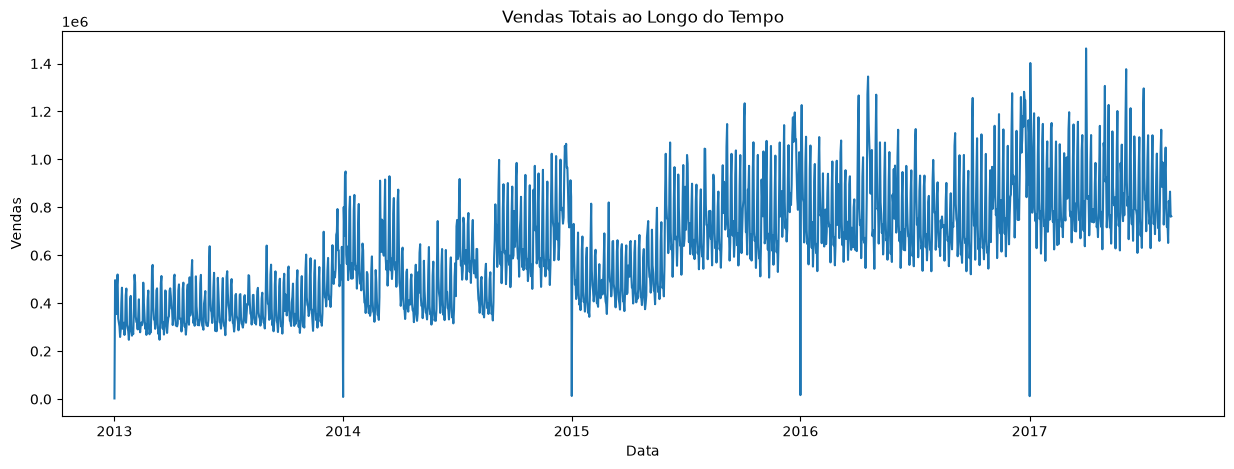

In [17]:
plt.figure(figsize=(15,5))
plt.plot(sales)
plt.title("Vendas Totais ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()

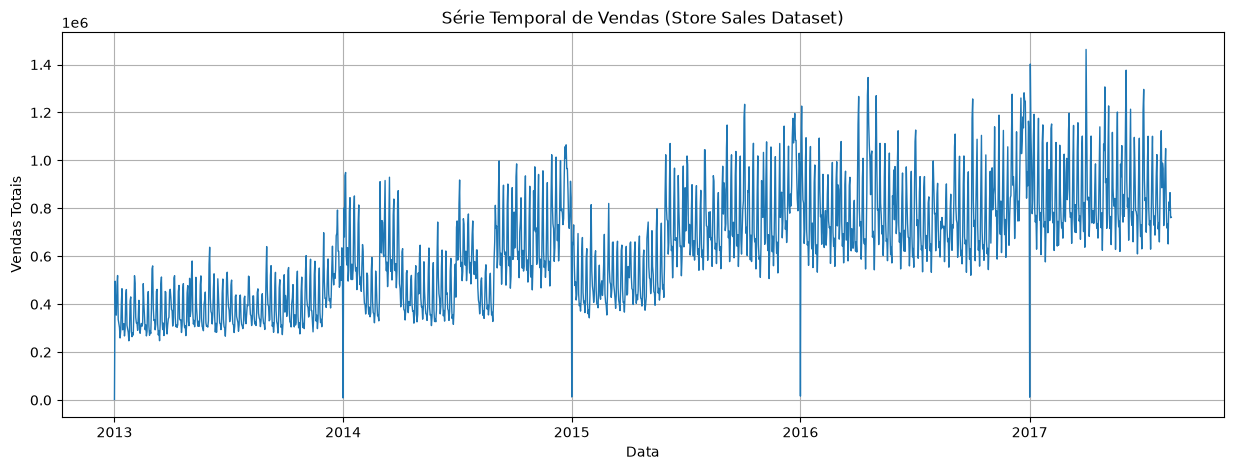

In [18]:
plt.figure(figsize=(15,5))
plt.plot(sales, linewidth=1)
plt.title("Série Temporal de Vendas (Store Sales Dataset)")
plt.xlabel("Data")
plt.ylabel("Vendas Totais")
plt.grid(True)
plt.show()

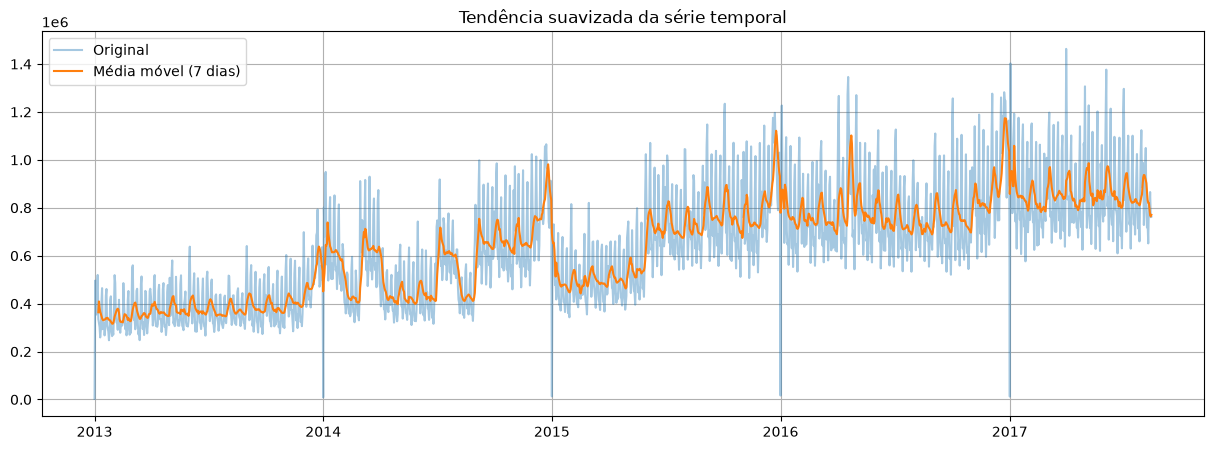

In [19]:
sales_ma7 = sales.rolling(window=7).mean()

plt.figure(figsize=(15,5))
plt.plot(sales, alpha=0.4, label="Original")
plt.plot(sales_ma7, label="Média móvel (7 dias)")
plt.legend()
plt.title("Tendência suavizada da série temporal")
plt.grid(True)
plt.show()

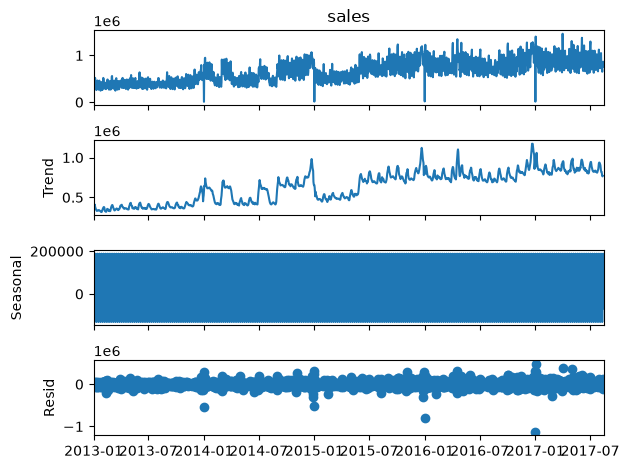

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(sales, model='additive', period=7)

result.plot()
plt.show()